# Bắt Đầu

## 1. khởi tạo

### 1.1 khởi tạo môi trường

In [1]:
# Kích thước ma trận
# ROWS = 6
# COLS = 6
#
# # Trạng thái ban đầu
# start_pos = (0, 0)
# goal_pos = (5, 5)
#
# # Danh sách các bước di chuyển hợp lệ (Trái, Phải, Lên, Xuống)
# actions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
#
# # Định nghĩa các bức tường (ngăn cách giữa 2 ô cụ thể)
# walls = [
#     ((0, 2), (0, 3)), ((1, 2), (1, 3)), # Tường dọc phía trên
#     ((4, 2), (4, 3)), ((5, 2), (5, 3)), # Tường dọc phía dưới
#     ((3, 4), (4, 4)), ((3, 5), (4, 5))  # Tường ngang phía phải
# ]
def read_maze_simple(filename):
    try:
        with open(filename, 'r') as f:
            # Đọc từng dòng, chuyển tất cả con số thành list số nguyên
            data = [list(map(int, line.split())) for line in f if line.strip()]

        if not data: return None

        # Dòng 0: Kích thước
        rows, cols = data[0][0], data[0][1]

        # Dòng 1: Start (x,y) và Goal (x,y)
        # data[1] là [0, 0, 5, 5]
        start_pos = (data[1][0], data[1][1])
        goal_pos = (data[1][2], data[1][3])

        # Các dòng còn lại: Tường (x1, y1, x2, y2)
        walls = []
        for line in data[2:]:
            # Gom [x1, y1, x2, y2] thành ((x1, y1), (x2, y2))
            wall_pair = ((line[0], line[1]), (line[2], line[3]))
            walls.append(wall_pair)

        return rows, cols, start_pos, goal_pos, walls

    except FileNotFoundError:
        print("Không tìm thấy file!")
        return None

ROWS, COLS, start_pos, goal_pos, walls = read_maze_simple('maze.txt')

## 2. tìm đường

### 2.1 hàm kiểm tra bước đi hợp lệ

In [2]:
def is_valid(current, next_node, walls, rows, cols):
    r, c = next_node
    if not (0 <= r < rows and 0 <= c < cols):
        return False
    if (current, next_node) in walls or (next_node, current) in walls:
        return False
    return True

### 2.2 hàm tạo đường đi

In [3]:
def reconstruct_path(visited, start, goal):
    if goal not in visited: return None
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = visited[curr]
    return path[::-1]

### 2.3 hàm tìm đường đi BFS

In [4]:
import heapq


def heuristic(a, b):
    # Sử dụng khoảng cách Manhattan: |x1 - x2| + |y1 - y2|
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def a_star(start, goal, walls, rows, cols):
    # Priority Queue lưu trữ các bộ: (độ ưu tiên f, node hiện tại)
    # Priority Queue mặc định của Python là min-heap
    pq = []
    heapq.heappush(pq, (0, start))

    # Lưu vết đường đi: {node: parent_node}
    came_from = {start: None}

    # Lưu chi phí g(n): {node: cost}
    cost_so_far = {start: 0}

    while pq:
        # Lấy node có f(n) thấp nhất
        current_f, current = heapq.heappop(pq)

        if current == goal:
            return reconstruct_path(came_from, start, goal)

        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            next_node = (current[0] + dr, current[1] + dc)

            if is_valid(current, next_node, walls, rows, cols):
                # Trong lưới ô vuông đơn giản, chi phí mỗi bước là 1
                new_cost = cost_so_far[current] + 1

                # Nếu node chưa đi qua HOẶC tìm được đường đi rẻ hơn đến node này
                if next_node not in cost_so_far or new_cost < cost_so_far[next_node]:
                    cost_so_far[next_node] = new_cost
                    # f(n) = g(n) + h(n)
                    priority = new_cost + heuristic(next_node, goal)
                    heapq.heappush(pq, (priority, next_node))
                    came_from[next_node] = current

    return None

## 3. các hàm hỗ trợ

In [5]:
import time

def print_path(path, name="Thuật toán"):
    if path:
        print(f"--- {name}: ({len(path) - 1} bước) ---")
        print(" -> ".join([str(p) for p in path]))
    else:
        print(f"--- {name}: Không tìm thấy đường đi! ---")


def benchmark(algo_func, name, *args):
    start_time = time.perf_counter()
    result = algo_func(*args)
    end_time = time.perf_counter()

    duration_ms = (end_time - start_time) * 1000
    print(f"\n[Thời gian chạy {name}]: {duration_ms:.4f} ms")
    return result

## 4. kết quả chạy được

In [13]:
%run Maze.py


[Thời gian chạy A* Search]: 0.1315 ms
--- A*: (10 bước) ---
(0, 0) -> (0, 1) -> (1, 1) -> (2, 1) -> (2, 2) -> (2, 3) -> (3, 3) -> (3, 4) -> (3, 5) -> (4, 5) -> (5, 5)


## 5. hàm vẽ thuật toán

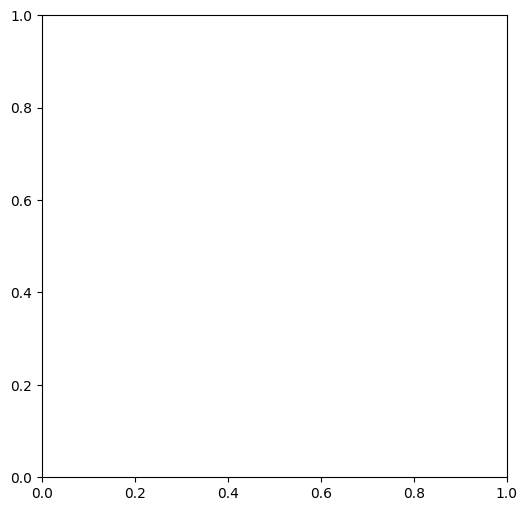

In [7]:
%run Maze.py

## 6. animation cho thuật toán(lưu vào file gif)

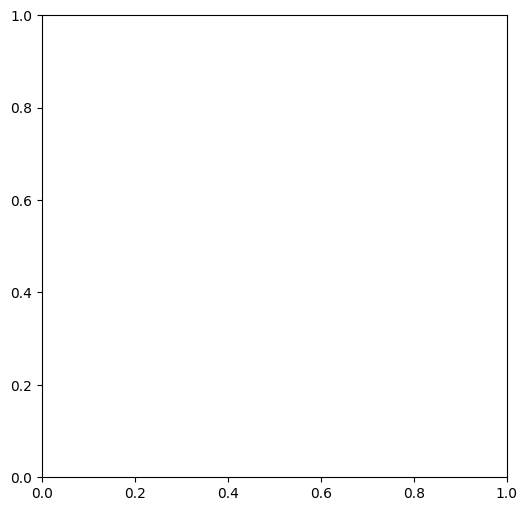

In [8]:
%run Maze.py

# Kết Thúc